In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import style


**Functions**

In [4]:
def sigmoid(z):
    g = 1/(1+np.exp(-z))
    return g

In [6]:
def compute_cost(X,y,w,b):
  m = X.shape[0]
  # Ensure y is a 2D column vector for consistent operations
  y = y.reshape(-1,1) if y.ndim == 1 else y

  # Calculate predictions: f_wb = sigmoid(X @ w + b)
  z_wb = np.dot(X, w) + b    # X (m,n), w (n,1), b scalar -> z_wb (m,1)
  f_wb = sigmoid(z_wb)       # f_wb (m,1)

  # Logistic regression cost function: J = -(1/m) * sum(y*log(f_wb) + (1-y)*log(1-f_wb))
  cost = (-y * np.log(f_wb) - (1 - y) * np.log(1 - f_wb)).sum() / m
  return cost

In [7]:
def compute_gradient(X,y,w,b):
  m=X.shape[0]
  y = y.reshape(-1,1) if y.ndim == 1 else y # Ensure y is a column vector

  z=X@w +b # X (m,n), w (n,1), b scalar -> z (m,1)
  f_wb=sigmoid(z) # f_wb (m,1)
  err=f_wb - y # err (m,1)
  dj_dw=X.T@err/m # X.T (n,m), err (m,1) -> dj_dw (n,1)
  dj_db=np.sum(err)/m # dj_db scalar

  return dj_dw,dj_db

In [8]:
def gradient_descent(X,y,w_in,b_in,alpha,iteration):
  J_history = []
  m=len(X)

  for i in range(iteration):
    dj_dw,dj_db = compute_gradient(X,y,w_in,b_in)

    w_in=w_in - alpha*dj_dw
    b_in=b_in - alpha*dj_db

    if i<100000:
      J_history.append(compute_cost(X,y,w_in,b_in))
    if i%np.ceil(iteration/10)==0:
      print(f"Iteration {i:4d}: Cost {J_history[-1]}")

  return w_in,b_in,J_history

In [9]:
def predict(X,w,b):
  m,n = X.shape
  p = np.zeros((m,1))
  for i in range(m):
    f_wb = sigmoid(np.dot(X[i],w) + b)
    if f_wb >= 0.5:
      p[i,0] = 1
    else:
      p[i,0] = 0
  return p

In [10]:
def accuracy(p,y):
  m=p.shape[0]
  c=0
  for i in range(m):
    if p[i]==y[i]:
      c +=1
  return c/m * 100

In [11]:
def zscore_normmalise(X):
  mean=np.mean(X,axis=0)
  std_dev=np.std(X,axis=0)
  X_norm=(X-mean)/std_dev
  return X_norm,mean,std_dev

In [12]:
def initialize_parameters(X):
  w=np.zeros((X.shape[1], 1)) # w should be a column vector (n, 1)
  b=0
  return w,b

In [13]:
def cost_vs_iteration(j):
  iterations=list(range(1,len(j)+1))
  style.use('ggplot')
  plt.plot(iterations,j)
  plt.title('Cost vs Iteration')
  plt.xlabel('Iterations')
  plt.ylabel('Cost')
  plt.show()

In [14]:
def graphical_analysis(x,y):
  n=x.shape[1]
  style.use('default')
  for i in range(n):
    plt.scatter(x[:,i],y,c='red')
    plt.title(f'Feature {i} and predicted output')
    plt.xlabel(f'Feature {i}')
    plt.ylabel('Target')
    plt.show()

**Reading**

In [15]:
df=pd.read_csv('/content/drive/MyDrive/WOC/train_binary.csv')
df

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,label
0,515.552122,0.501142,5333.319937,172.962979,0.004575,46549.221548,502.584920,0.458395,4625.879935,151.521484,...,144.258303,0.789506,2865.992302,160.440862,0.694201,1694.929183,1.496844,0.146772,1.0,1
1,668.286985,0.508581,4370.282875,128.300296,0.004639,44025.018827,636.168692,0.467422,3879.914621,107.274618,...,62.304522,1.017827,2472.959367,124.381135,0.401894,2443.117516,0.846703,0.215638,1.0,0
2,517.168489,0.483042,3326.280886,75.704752,0.004040,52406.140385,492.702393,0.444783,2869.670905,60.559518,...,111.695965,0.861554,1790.204707,153.325634,0.813255,1469.394258,1.742825,-0.231080,-1.0,1
3,417.096784,0.487056,6286.092355,102.207298,0.004742,36243.588753,397.695808,0.447867,5592.085691,81.986835,...,35.834294,0.921524,2881.303663,90.376685,0.253066,2684.461934,1.286850,0.354612,1.0,0
4,427.939556,0.498989,3768.307841,124.954769,0.004527,45977.266327,417.109675,0.460051,3413.620214,88.142404,...,71.319597,0.898992,3037.465775,163.221910,0.877538,1387.321736,1.328970,0.190285,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,789.738008,0.505044,4642.527900,132.573113,0.005109,69399.509731,747.979160,0.465992,4063.174493,100.867779,...,90.109806,1.081448,3088.924472,127.561973,0.722487,1252.416430,0.743094,0.212048,1.0,1
49996,457.579612,0.489933,4160.563769,77.606157,0.004482,45170.024317,441.381634,0.452301,3506.768205,86.154599,...,76.398822,1.054955,2616.092066,89.180417,0.581472,2291.196899,0.951445,0.250033,1.0,0
49997,578.638788,0.491047,6981.908457,93.660410,0.005357,35522.229160,542.960571,0.456214,6354.989341,80.453576,...,120.791832,1.045450,2094.438849,132.862747,0.765753,1288.654796,1.985960,-0.517229,-1.0,1
49998,403.147958,0.498460,4892.332330,0.054805,0.004812,58012.239393,374.700993,0.459468,4528.013421,-7.520896,...,78.016204,0.829848,3070.158801,93.126832,0.528168,2388.419746,2.001801,-0.151026,1.0,0


In [16]:
df.describe()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,label
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,500.646426,0.499961,5001.475347,99.663713,0.005001,50004.809044,475.641138,0.459966,4401.601767,84.672616,...,74.912848,0.999289,2495.055679,115.182153,0.591371,2056.161274,1.277149,0.003311,-0.002680,0.303600
std,102.167451,0.010176,1018.686318,50.946605,0.001021,10193.068407,97.407907,0.009576,899.975387,44.935452,...,25.024744,0.100383,498.380114,27.473200,0.159825,418.518026,0.666971,1.042740,1.000006,0.459817
min,44.552292,0.462030,966.650179,-130.775155,0.000618,6888.787646,37.323957,0.421474,877.269883,-106.825468,...,-20.047149,0.540305,476.137094,41.911967,0.156876,729.555101,0.008627,-9.263822,-1.000000,0.000000
25%,431.558647,0.493091,4313.706744,65.277365,0.004320,43098.759523,409.719004,0.453495,3794.988088,54.217184,...,57.922540,0.932153,2156.137582,94.564638,0.471014,1686.072685,0.775074,-0.375392,-1.000000,0.000000
50%,500.723423,0.499944,5000.138426,99.838686,0.005002,50049.357109,475.743828,0.459978,4403.108013,84.700557,...,74.865170,0.999356,2497.297022,108.480117,0.546799,2181.189715,1.203037,0.000198,-1.000000,0.000000
75%,570.043673,0.506870,5686.792287,134.056839,0.005688,56864.960088,541.822674,0.466470,5008.693250,115.092937,...,91.921637,1.066220,2832.091910,136.839835,0.728151,2371.657805,1.692574,0.380763,1.000000,1.000000
max,930.857578,0.541910,9061.589352,332.284250,0.008894,95723.410815,882.181943,0.498576,8043.777043,272.166998,...,174.186524,1.461638,4572.047464,208.654969,1.167666,3058.142671,4.946865,9.609629,1.000000,1.000000


In [17]:

df_train=df.head(40000)
df_cv=df.tail(10000)
X_train=df_train.drop('label',axis=1).to_numpy()
y_train=df_train['label'].to_numpy()
X_cv=df_cv.drop('label',axis=1).to_numpy()
y_cv=df_cv['label'].to_numpy()
X_train


array([[ 5.15552122e+02,  5.01142287e-01,  5.33331994e+03, ...,
         1.49684358e+00,  1.46772301e-01,  1.00000000e+00],
       [ 6.68286985e+02,  5.08580815e-01,  4.37028287e+03, ...,
         8.46703232e-01,  2.15638436e-01,  1.00000000e+00],
       [ 5.17168489e+02,  4.83041619e-01,  3.32628089e+03, ...,
         1.74282509e+00, -2.31079875e-01, -1.00000000e+00],
       ...,
       [ 5.89686882e+02,  5.03544498e-01,  4.89984458e+03, ...,
         2.54646349e-01,  1.19274707e-01,  1.00000000e+00],
       [ 5.76663487e+02,  4.96552757e-01,  6.15648463e+03, ...,
         1.57085850e+00, -9.64472384e-01, -1.00000000e+00],
       [ 7.00867484e+02,  5.15587093e-01,  5.24299048e+03, ...,
         4.13048514e-01, -1.11434264e-01,  1.00000000e+00]])

In [18]:
X_train_norm,mean,std_dev=zscore_normmalise(X_train)


In [19]:
X_cv_norm=(X_cv-mean)/std_dev

In [20]:
X_train_norm.shape

(40000, 25)

In [33]:
w,b = initialize_parameters(X_train_norm)

In [34]:
w.shape


(25, 1)

In [35]:
interation=5000
alpha=0.02
w,b,j=gradient_descent(X_train_norm,y_train,w,b,alpha,interation)

Iteration    0: Cost 0.6783157866877128
Iteration  500: Cost 0.072642120781322
Iteration 1000: Cost 0.043085977058747935
Iteration 1500: Cost 0.03173980531538217
Iteration 2000: Cost 0.025596216019852357
Iteration 2500: Cost 0.021696608827107194
Iteration 3000: Cost 0.018980499526114896
Iteration 3500: Cost 0.01696937254999186
Iteration 4000: Cost 0.015414160424051826
Iteration 4500: Cost 0.014171842264981504


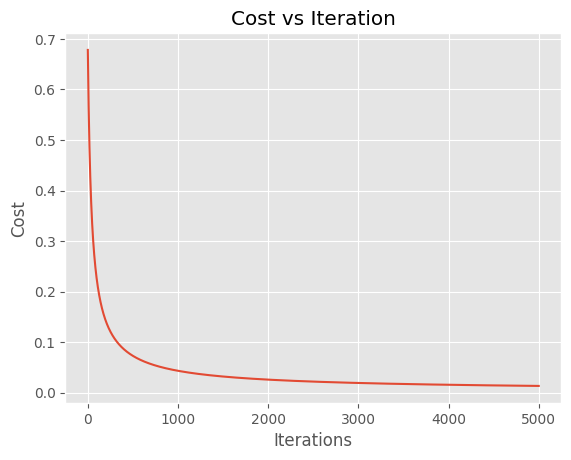

In [36]:
cost_vs_iteration(j)

**Accuracy**

In [37]:
p=predict(X_train_norm,w,b)
print(accuracy(p,y_train))

99.92


In [38]:
p=predict(X_cv_norm,w,b)
print(accuracy(p,y_cv))

99.92999999999999


**Test Data**

In [39]:
data=pd.read_csv('/content/drive/MyDrive/WOC/test_binary.csv')


In [40]:
X_test=data.to_numpy()
X_test_norm=(X_test-mean)/std_dev
X_test_norm.shape

(25000, 25)

In [41]:
w.shape

(25, 1)

In [42]:
prediction=predict(X_test_norm,w,b)
prediction.shape

(25000, 1)

In [43]:
pred=pd.DataFrame(prediction,columns=['Predection'])
pred

,Predection
0,0.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
24995,1.0
24996,1.0
24997,1.0
24998,1.0


In [44]:
pred.to_csv('Logistic_Regression_prediction.csv',index=False)